<a href="https://colab.research.google.com/github/25041066NegreteSimentalJuanDiego/Probabilidad-y-Estadistica/blob/main/Unidad6/ProyectoFinalU6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probabilidad y Estadistica
# Grupo:2YY
# UNIDAD 6
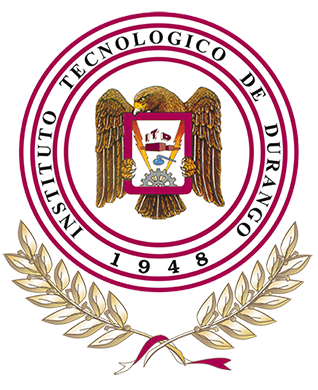
# Fecha: 23/05/2026
## integrantes:
### - Abrego Reyes Angel Felipe
### - Leal Salazar Erik Leonardo
### - Negrete Simental Juan Diego
##Facilitador:Jose Gabriel Rodriguez Rivas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from google.colab import drive
from google.colab import files

drive.mount('/content/drive')
df = pd.read_csv(
    '/content/drive/MyDrive/PyE/covid2020-2021-codificado.csv',
    encoding='utf-8'
)
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Contenido del análisis

In [3]:
from pandas.core.api import value_counts


print("============Resultados de analisis covid=============")
pp=(df['RESULTADO_ANTIGENO']=="Positivo").sum()
print("Positivos:", pp)
pn=(df['RESULTADO_ANTIGENO']=="Negativo").sum()
print("Negativos:", pn)
pps=(df['RESULTADO_ANTIGENO']=="Pendiente").sum()
print("Pendientes:",pps)

print("============Hospitalizados y ambulatorios=============")
pa=(df['TIPO_PACIENTE']=="Ambulatorio").sum()
print("Ambulatorios:", pa)
ph=(df['TIPO_PACIENTE']=="Hospitalizado").sum()
print("Hospitalizados:", ph)
print("============Pacientes embarazadas=============")
embarazadas=(df['EMBARAZO'] == 'Si').sum()
print("Pacientes embarazadas:", embarazadas)
Nembarazadas=(df['EMBARAZO'] == 'No').sum()
print("Pacientes NO embarazadas:", Nembarazadas)
Noap=(df['EMBARAZO'] == 'No aplica').sum()
print("NO aplica:", Noap)
ign=(df['EMBARAZO'] == 'Se ignora').sum()
print("Se ignora:", ign)
print("============Pacientes Indigenas==============")
indi=(df['INDIGENA'] == 'Si').sum()
print("Pacientes Indigenas:", indi)
Nindi=(df['INDIGENA'] == 'No').sum()
print("Pacientes NO Indigenas:", Nindi)
nei=(df['INDIGENA'] == 'No especificado').sum()
print("No especificado:", nei)



============Resultados de analisis covid=============
Positivos: 1774708
Negativos: 5853547
Pendientes: 5005939
============Hospitalizados y ambulatorios=============
Ambulatorios: 11543303
Hospitalizados: 1090891
============Pacientes embarazadas=============
Pacientes embarazadas: 122583
Pacientes NO embarazadas: 6483614
NO aplica: 5985456
Se ignora: 42529
============Pacientes Indigenas==============
Pacientes Indigenas: 35240
Pacientes NO Indigenas: 3665974
No especificado: 167182


No se si esto se deba de explicar, creo que como se muestran estan bien :P

#Visualicaciones

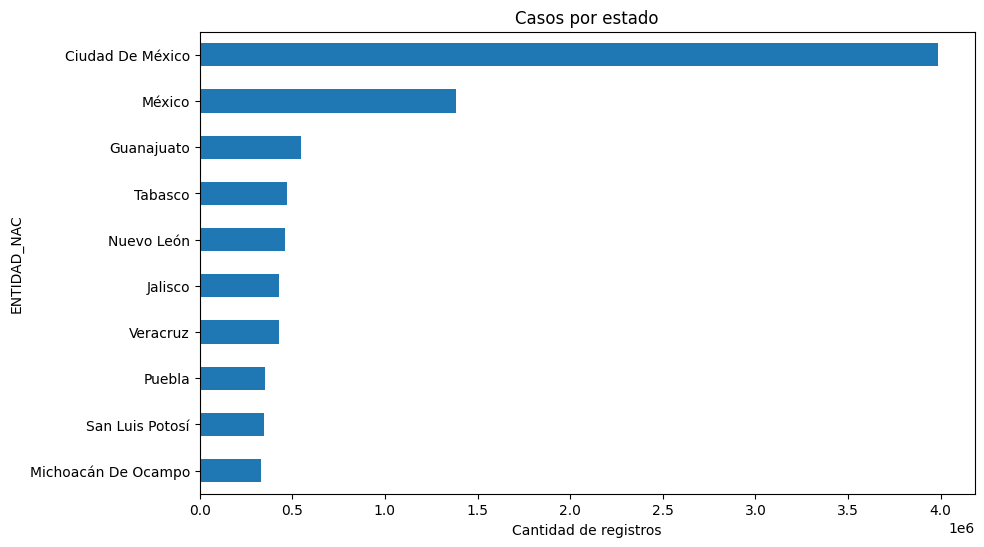

In [4]:
estado = df['ENTIDAD_NAC'].value_counts().head(10)

plt.figure(figsize=(10,6))

estado.sort_values().plot(kind='barh')
plt.title('Casos por estado')
plt.xlabel('Cantidad de registros')
plt.show()

En esta grafica de barras de barras horizontales que muestra los 10 estados con más casos registrados de COVID en México, ordenados de mayor a menor.

Ciudad de México domina completamente. Con casi 4 millones de registros, está muy por encima de todos los demás estados. La diferencia es tan grande que visualmente aplasta al resto, lo que nos dice que CDMX concentró una parte enorme de los casos a nivel nacional.

Estado de México es el segundo lugar, con alrededor de 1.4 millones, pero ya representa menos de la mitad de CDMX. Esto tiene sentido dado que ambas son las zonas más pobladas y densas del país.

Del 3° al 10° lugar hay poca diferencia entre sí. Guanajuato, Tabasco, Nuevo León, Jalisco, Veracruz, Puebla, San Luis Potosí y Michoacán están todos entre aproximadamente 300,000 y 550,000 casos, con variaciones relativamente pequeñas entre ellos.

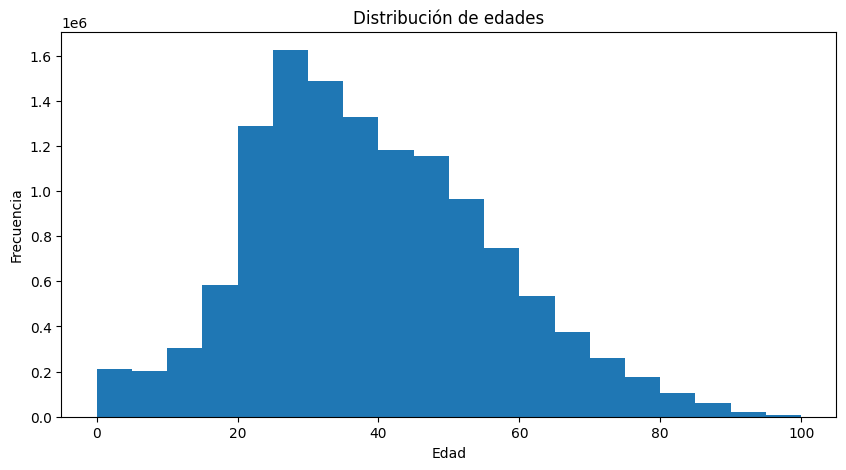

In [5]:
df_edades = df[(df['EDAD'] >= 0) & (df['EDAD'] <= 100)]
plt.figure(figsize=(10,5))

plt.hist(df_edades['EDAD'], bins=20)

plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

 En este histograma se muestra cómo se distribuyen las edades de los pacientes registrados con COVID en México. Cada barra representa un rango de edad y su altura indica cuántos pacientes caen en ese rango.

La edad más afectada en términos de cantidad de casos fue la población joven-adulta (20-40 años). Sin embargo, hay que tener en cuenta esto al interpretar el histograma: más casos no significa más gravedad. Los adultos mayores, aunque menos en número, probablemente tuvieron tasas de hospitalización y mortalidad mucho más altas

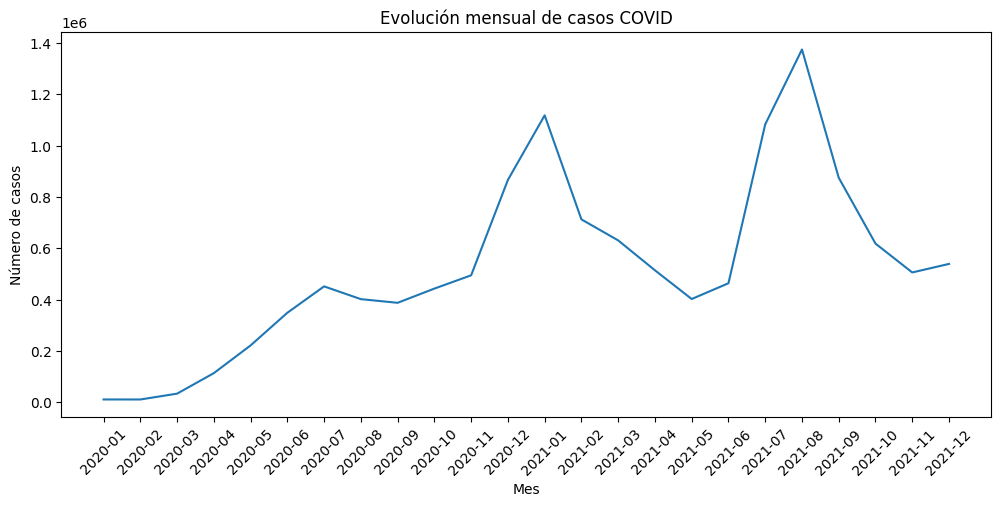

In [6]:
df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'])
casos_mes = df.groupby(df['FECHA_INGRESO'].dt.to_period('M')).size()
plt.figure(figsize=(12,5))

plt.plot(casos_mes.index.astype(str), casos_mes.values)

plt.title('Evolución mensual de casos COVID')
plt.xlabel('Mes')
plt.ylabel('Número de casos')

plt.xticks(rotation=45)

plt.show()

En esta gráfica de línea temporal se muestra cómo evolucionaron los casos de COVID mes a mes en México, desde enero de 2020 hasta diciembre de 2021.

Esta grafica demuestra que la pandemia en México no tuvo una sola ola sino un patrón de picos y valles, con la segunda ola siendo la más severa. Los periodos vacacionales y la aparición de nuevas variantes fueron factores clave en los repuntes.

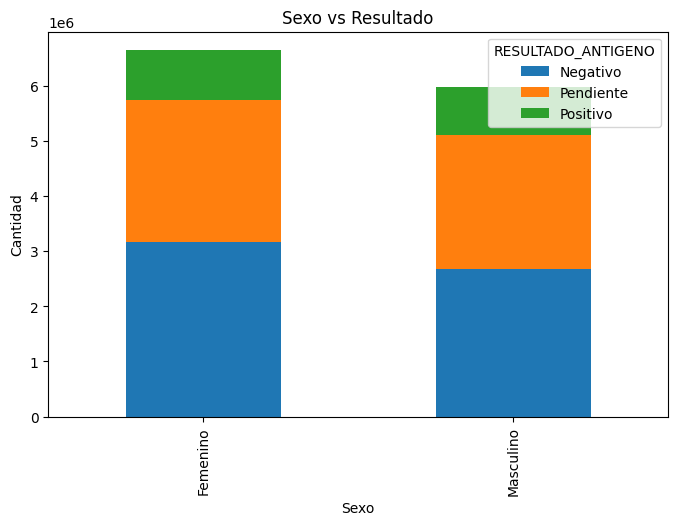

In [7]:
tabla = pd.crosstab(df['SEXO'], df['RESULTADO_ANTIGENO'])

tabla.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Sexo vs Resultado')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')

plt.show()

En esta  gráfica de barras apiladas se compara el resultado de la prueba de antígeno (Negativo, Pendiente, Positivo) entre pacientes de sexo Femenino y Masculino.

Se interpeta como que no hay una diferencia dramática entre sexos en cuanto a resultados. Lo más relevante de esta gráfica es la enorme cantidad de resultados Pendientes, que refleja la saturación del sistema de salud y los rezagos en el registro de pruebas durante la pandemia.

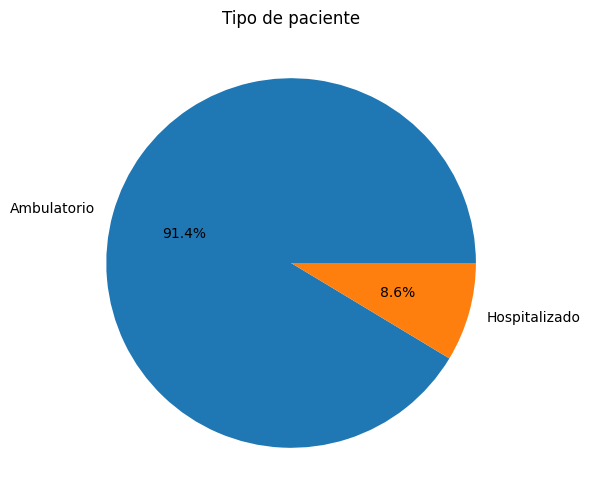

In [8]:
tipo = df['TIPO_PACIENTE'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(tipo,
        labels=['Ambulatorio','Hospitalizado'],
        autopct='%1.1f%%')

plt.title('Tipo de paciente')

plt.show()

En esta gráfica de pastel se divide a todos los pacientes registrados en dos categorías: los que fueron atendidos de forma ambulatoria (en casa o consulta) y los que requirieron hospitalización.

Esta gráfica es importante porque desmitifica y a la vez confirma dos cosas al mismo tiempo: por un lado, la mayoría de los casos de COVID fueron manejables sin hospitalización, lo que es una buena noticia. Por otro lado, un 8.6% de millones de casos es suficiente para colapsar hospitales.

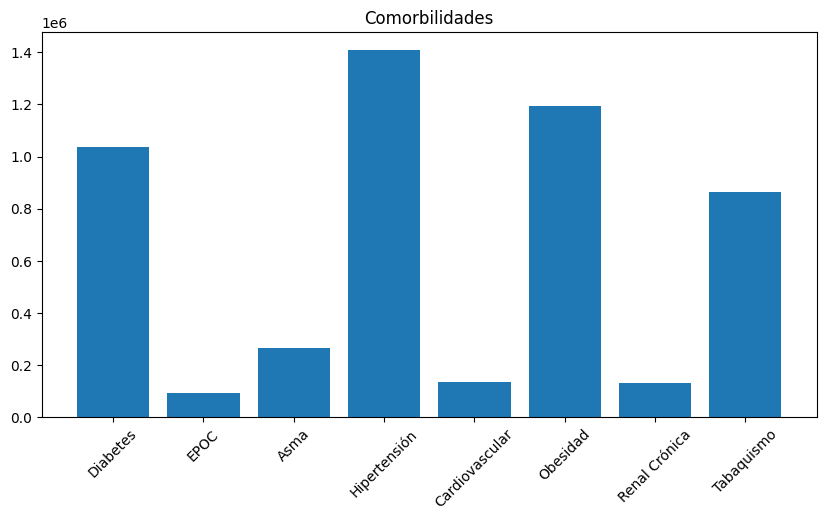

In [9]:
comorbilidades = {
    'Diabetes': (df['DIABETES'] == 'Si').sum(),
    'EPOC': (df['EPOC'] == 'Si').sum(),
    'Asma': (df['ASMA'] == 'Si').sum(),
    'Hipertensión': (df['HIPERTENSION'] =='Si').sum(),
    'Cardiovascular': (df['CARDIOVASCULAR'] == 'Si').sum(),
    'Obesidad': (df['OBESIDAD'] == 'Si').sum(),
    'Renal Crónica': (df['RENAL_CRONICA'] == 'Si').sum(),
    'Tabaquismo': (df['TABAQUISMO'] == 'Si').sum()
}

plt.figure(figsize=(10,5))

plt.bar(comorbilidades.keys(), comorbilidades.values())

plt.xticks(rotation=45)

plt.title('Comorbilidades')

plt.show()

En esta gráfica de barras verticales que muestra cuántos pacientes COVID tenían cada una de las principales comorbilidades (enfermedades previas) registradas en el dataset.

El perfil de comorbilidades refleja perfectamente la crisis de salud pública de México previo al COVID: hipertensión, obesidad y diabetes forman un triángulo de riesgo muy presente en la población. Esto explica en parte por qué México tuvo tasas de mortalidad más altas que otros países con poblaciones similares.

In [10]:
print(df.columns.tolist())

['SECTOR', 'SEXO', 'ENTIDAD_NAC', 'TIPO_PACIENTE', 'FECHA_INGRESO', 'FECHA_DEF', 'INTUBADO', 'NEUMONIA', 'EDAD', 'EMBARAZO', 'INDIGENA', 'DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO', 'RESULTADO_ANTIGENO', 'UCI']


## 4. Probabilidades por Comorbilidad e Interpretación Estadística

In [11]:
# ============================================
# PUNTO 4 - PROBABILIDADES POR COMORBILIDAD
# ============================================

comorbilidades = [
    'DIABETES',
    'HIPERTENSION',
    'OBESIDAD',
    'EPOC',
    'ASMA',
    'RENAL_CRONICA',
    'CARDIOVASCULAR',
    'TABAQUISMO'
]

# ============================================
# TOTAL GENERAL DE CASOS
# ============================================

total_casos = len(df)

print("TOTAL GENERAL DE CASOS:", total_casos)


TOTAL GENERAL DE CASOS: 12634194


In [12]:
# ============================================
# PROBABILIDAD SIMPLE
# ============================================

print("\n===================================")
print("PROBABILIDAD SIMPLE")
print("===================================\n")

for comorb in comorbilidades:

    # Contar los "Si"
    total_comorb = (df[comorb] == 'Si').sum()

    probabilidad = total_comorb / total_casos

    print(f"{comorb}")
    print(f"Pacientes con la comorbilidad: {total_comorb}")
    print(f"Probabilidad: {probabilidad:.4f}")
    print(f"Porcentaje: {probabilidad*100:.2f}%\n")


PROBABILIDAD SIMPLE

DIABETES
Pacientes con la comorbilidad: 1038459
Probabilidad: 0.0822
Porcentaje: 8.22%

HIPERTENSION
Pacientes con la comorbilidad: 1407779
Probabilidad: 0.1114
Porcentaje: 11.14%

OBESIDAD
Pacientes con la comorbilidad: 1193021
Probabilidad: 0.0944
Porcentaje: 9.44%

EPOC
Pacientes con la comorbilidad: 92446
Probabilidad: 0.0073
Porcentaje: 0.73%

ASMA
Pacientes con la comorbilidad: 263855
Probabilidad: 0.0209
Porcentaje: 2.09%

RENAL_CRONICA
Pacientes con la comorbilidad: 129874
Probabilidad: 0.0103
Porcentaje: 1.03%

CARDIOVASCULAR
Pacientes con la comorbilidad: 134410
Probabilidad: 0.0106
Porcentaje: 1.06%

TABAQUISMO
Pacientes con la comorbilidad: 865162
Probabilidad: 0.0685
Porcentaje: 6.85%



In [13]:
# ============================================
# --- PROBABILIDAD CONDICIONAL POR ENTIDAD ---
# ============================================

print("\n===================================")
print("PROBABILIDAD CONDICIONAL POR ENTIDAD")
print("===================================\n")

for comorb in comorbilidades:

    print(f"\n===== {comorb} =====\n")

    resultados = []

    entidades = sorted(df['ENTIDAD_NAC'].unique())

    for entidad in entidades:

        datos_entidad = df[df['ENTIDAD_NAC'] == entidad]

        total_entidad = len(datos_entidad)

        casos_comorb = (datos_entidad[comorb] == 'Si').sum()

        prob_condicional = casos_comorb / total_entidad

        resultados.append({
            'Entidad': entidad,
            'Probabilidad': round(prob_condicional, 4)
        })

    tabla = pd.DataFrame(resultados)

    print(tabla)



PROBABILIDAD CONDICIONAL POR ENTIDAD


===== DIABETES =====

                 Entidad  Probabilidad
0                     99        0.0243
1         Aguascalientes        0.0757
2        Baja California        0.0850
3    Baja California Sur        0.0718
4               Campeche        0.0879
5                Chiapas        0.0824
6              Chihuahua        0.1056
7       Ciudad De México        0.0651
8   Coahuila De Zaragoza        0.0946
9                 Colima        0.0802
10               Durango        0.0912
11            Guanajuato        0.0927
12              Guerrero        0.1057
13               Hidalgo        0.1192
14               Jalisco        0.1082
15   Michoacán De Ocampo        0.0903
16               Morelos        0.0727
17                México        0.0668
18               Nayarit        0.0955
19            Nuevo León        0.0918
20                Oaxaca        0.0986
21                Puebla        0.1074
22             Querétaro        0.0838
23

In [14]:
# ============================================
# --- PROBABILIDAD CONDICIONAL POR ENTIDAD ---
# ============================================

print("\n===================================")
print("PROBABILIDAD CONDICIONAL POR ENTIDAD")
print("===================================\n")

for comorb in comorbilidades:

    print(f"\n===== {comorb} =====\n")

    tabla = (
        (df[comorb] == 'Si')
        .groupby(df['ENTIDAD_NAC'])
        .mean()
        .reset_index()
    )

    tabla.columns = ['Entidad', 'Probabilidad']

    tabla['Probabilidad'] = tabla['Probabilidad'].round(4)

    print(tabla)


PROBABILIDAD CONDICIONAL POR ENTIDAD


===== DIABETES =====

                 Entidad  Probabilidad
0                     99        0.0243
1         Aguascalientes        0.0757
2        Baja California        0.0850
3    Baja California Sur        0.0718
4               Campeche        0.0879
5                Chiapas        0.0824
6              Chihuahua        0.1056
7       Ciudad De México        0.0651
8   Coahuila De Zaragoza        0.0946
9                 Colima        0.0802
10               Durango        0.0912
11            Guanajuato        0.0927
12              Guerrero        0.1057
13               Hidalgo        0.1192
14               Jalisco        0.1082
15   Michoacán De Ocampo        0.0903
16               Morelos        0.0727
17                México        0.0668
18               Nayarit        0.0955
19            Nuevo León        0.0918
20                Oaxaca        0.0986
21                Puebla        0.1074
22             Querétaro        0.0838
23

## 5. Ejercicio de distribucion normal


In [15]:
from scipy import stats

# Parámetros de la distribución
media = 2360
desv_std = 714

# Probabilidad de que un estado tenga entre 2000 y 3000 casos positivos
prob = stats.norm.cdf(3000, loc=media, scale=desv_std) - \
      stats.norm.cdf(2000, loc=media, scale=desv_std)

print(f"Probabilidad de que un estado tenga entre 2000 y 3000 casos positivos = {prob:.4f}")
print(f"En porcentaje: {prob * 100:.2f}%")

Probabilidad de que un estado tenga entre 2000 y 3000 casos positivos = 0.5079
En porcentaje: 50.79%


En este punto se observa la probabilidad de que un estado tenga entre 2000 y 3000 casos positivos de covid en base a la media (2360) y la desviacion estandar (714), dando como resultado que existe un 50.79% de que un estado tenga dichos casos positivos, siendo demasidado probale ya que es la mitad de la probabilidad

# 6. Conclusiones personales


# Abrego Reyes
#####Durante la asignartura pude conocer distintas formas de analizar la informacion y clasificarla, con ayuda de visualizaciones como grafica de barras ,pasteles,etc, es mas facil poder hacer una probabilidad de que un evento pase en base a la informacion dada como cuantas veces ocurre un evento, donde ocurre y como. Hacerlo con herramientas como las que ofrece python lo hace mas eficiente, mas rapido y mas amigable para entender lo que esta pasando


## Leal Salazar Erik Leonardo
Lo que aprendí en la asignarura fue a usar la programación para sacar porcentajes o probabilidades, ya que antes pues hacia los ejercicios por lo que el usar Python para esto es mucho mas sencillo y rapido, personalmente me gusto mucho usar Python ya que nunca fui bueno para sacar porcentajes y aqui con Python es muy sencillo y facil.

##Negrete Simental Juan Diego
#####En conclusión, en esta materia aprendí que la probabilidad y la estadística no solo son fórmulas, sino herramientas que sirven para analizar situaciones reales. Durante el semestre vimos temas como distribución normal, Poisson, probabilidades y análisis de datos, y gracias a eso fue más fácil entender cómo interpretar información y sacar conclusiones a partir de datos.

#####También aprendí a usar Python para hacer cálculos, organizar datos y crear gráficas, lo que hizo las actividades más prácticas e interesantes. En general, la materia me ayudó a entender mejor cómo se aplica la estadística en problemas reales y a mejorar un poco mis habilidades de programación.